In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns   
import numpy as np
import re
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# Load data hasil scraping
df = pd.read_csv('dataset_efootball_raw.csv')
print(f"Total data: {len(df)}")

Total data: 10621


In [3]:
df.head()

,Review,Rating
0,boleh lah,5
1,JARINGAN LU BENERIN NAPA KONAMEK,1
2,oke lah tapih respon sif kurang cepat sih,1
3,plis dong buat pihak konami tambahin klub fc b...,5
4,sangat puas,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10621 entries, 0 to 10620
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  10621 non-null  object
 1   Rating  10621 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 166.1+ KB


In [5]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # Menghapus mention (username)
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # Menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # Menghapus retweet (RT)
    text = re.sub(r"http\S+", '', text) # Menghapus URL/link
    text = re.sub(r'[0-9]+', '', text) # Menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # Menghapus karakter selain huruf dan spasi

    text = text.replace('\n', ' ') # Mengganti newline dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # Menghapus tanda baca
    text = text.strip(' ') # Menghapus spasi di awal dan akhir teks
    return text

def casefoldingText(text): # Mengubah seluruh huruf menjadi huruf kecil (lowercase)
    text = text.lower()
    return text

def tokenizingText(text): # Memecah teks menjadi daftar token/kata
    text = word_tokenize(text)
    return text

def filteringText(text): # Menghapus stopword (bahasa Indonesia & Inggris + tambahan custom)
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengubah kata menjadi bentuk dasar (stemming)
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Melakukan stemming pada setiap kata
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kembali kata menjadi kalimat
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

    return stemmed_text

def toSentence(list_words): # Menggabungkan list kata menjadi satu kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [6]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}
# slangwords khusus efootball
efootball_slang = {
    "ngeleg": "lambat",
    "ngelag": "lambat",
    "lag": "lambat",
    "ampas": "buruk",
    "buriq": "buruk",
    "burik": "buruk",
    "gacor": "bagus",
    "cit": "curang",
    "cheater": "curang",
    "ngecit": "curang",
    "scrip": "skenario", # Merujuk pada 'scripting' yang sering dikeluhkan pengguna
    "skrip": "skenario",
    "koin": "uang",
    "gp": "poin",
    "nyesel": "menyesal",
    "kecewa": "buruk",
    "lanjay": "lancar",
    "payah": "buruk",
    "sinyal": "koneksi",
    "mabar": "main bareng",
    "akun": "profil",
    "ilang": "hilang",
    "topup": "isi saldo",
    "taktik": "strategi"
}

# gabungkan dengan slangwords umum
slangwords.update(efootball_slang)

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [7]:
df

,Review,Rating
0,boleh lah,5
1,JARINGAN LU BENERIN NAPA KONAMEK,1
2,oke lah tapih respon sif kurang cepat sih,1
3,plis dong buat pihak konami tambahin klub fc b...,5
4,sangat puas,5
...,...,...
10616,lope you,5
10617,nambah parah nihh game lagi maen kenapa tiba t...,1
10618,"Game nya bagus tapi, dari gaca epic ampas, kon...",1
10619,"game apa ini lama²kok sekrng ada iklan nya, ma...",1


In [8]:

# Membersihkan noise pada teks (simbol, link, angka) dan disimpan ke kolom 'text_clean'
df['text_clean'] = df['Review'].apply(cleaningText)

# Penyeragaman format huruf (kecil semua) untuk memudahkan pencocokan kata dasar
df['text_casefoldingText'] = df['text_clean'].apply(casefoldingText)

# Normalisasi istilah: Mengonversi bahasa gaul/slang ke bahasa standar (Bahasa Indonesia baku)
df['text_slangwords'] = df['text_casefoldingText'].apply(fix_slangwords)

# Tahap Tokenisasi: Memecah kalimat menjadi potongan kata tunggal (token)
df['text_tokenizingText'] = df['text_slangwords'].apply(tokenizingText)

# Filtrasi Stopwords: Mengeliminasi kata umum yang tidak membawa bobot nilai sentimen
df['text_stopword'] = df['text_tokenizingText'].apply(filteringText)

# Rekonstruksi kalimat: Menggabungkan kembali token yang sudah bersih menjadi kalimat utuh
df['text_akhir'] = df['text_stopword'].apply(toSentence)


In [9]:
df

,Review,Rating,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,boleh lah,5,boleh lah,boleh lah,boleh lah,"[boleh, lah]",[],
1,JARINGAN LU BENERIN NAPA KONAMEK,1,JARINGAN LU BENERIN NAPA KONAMEK,jaringan lu benerin napa konamek,jaringan kamu benerin kenapa konamek,"[jaringan, kamu, benerin, kenapa, konamek]","[jaringan, benerin, konamek]",jaringan benerin konamek
2,oke lah tapih respon sif kurang cepat sih,1,oke lah tapih respon sif kurang cepat sih,oke lah tapih respon sif kurang cepat sih,oke lah tapih respon sif kurang cepat sih,"[oke, lah, tapih, respon, sif, kurang, cepat, ...","[oke, tapih, respon, sif, cepat]",oke tapih respon sif cepat
3,plis dong buat pihak konami tambahin klub fc b...,5,plis dong buat pihak konami tambahin klub fc b...,plis dong buat pihak konami tambahin klub fc b...,tolong dong buat pihak konami tambahin klub fc...,"[tolong, dong, buat, pihak, konami, tambahin, ...","[tolong, konami, tambahin, klub, fc, bayern, m...",tolong konami tambahin klub fc bayern munchen ...
4,sangat puas,5,sangat puas,sangat puas,sangat puas,"[sangat, puas]",[puas],puas
...,...,...,...,...,...,...,...,...
10616,lope you,5,lope you,lope you,lope you,"[lope, you]",[lope],lope
10617,nambah parah nihh game lagi maen kenapa tiba t...,1,nambah parah nihh game lagi maen kenapa tiba t...,nambah parah nihh game lagi maen kenapa tiba t...,nambah parah nihh game lagi main kenapa tiba t...,"[nambah, parah, nihh, game, lagi, main, kenapa...","[nambah, parah, nihh, game, main, kalah, jarin...",nambah parah nihh game main kalah jaringan bagus
10618,"Game nya bagus tapi, dari gaca epic ampas, kon...",1,Game nya bagus tapi dari gaca epic ampas konek...,game nya bagus tapi dari gaca epic ampas konek...,game nya bagus tapi dari gaca epic buruk konek...,"[game, nya, bagus, tapi, dari, gaca, epic, bur...","[game, bagus, gaca, epic, buruk, koneksi, buru...",game bagus gaca epic buruk koneksi buruk gilir...
10619,"game apa ini lama²kok sekrng ada iklan nya, ma...",1,game apa ini lama²kok sekrng ada iklan nya mak...,game apa ini lama²kok sekrng ada iklan nya mak...,game apa ini lama²kok sekrng ada iklan nya mak...,"[game, apa, ini, lama²kok, sekrng, ada, iklan,...","[game, lama²kok, sekrng, iklan, kesini, gajela...",game lama²kok sekrng iklan kesini gajelas game


## Pelabelan

In [10]:
import csv
import requests
from io import StringIO

# LOAD KAMUS LEXICON Dari github 

# Membaca data kamus kata-kata positif
lexicon_positive = dict()
response_pos = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response_pos.status_code == 200:
    reader = csv.reader(StringIO(response_pos.text), delimiter=',')
    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif
lexicon_negative = dict()
response_neg = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response_neg.status_code == 200:
    reader = csv.reader(StringIO(response_neg.text), delimiter=',')
    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")




In [11]:
#  FUNGSI PELABELAN (POSITIVE, NEGATIVE, NEUTRAL)
def calculate_sentiment(text):
    score = 0
    words = str(text).split() # Memastikan input adalah string
    
    for word in words:
        # Tambah skor jika kata ada di kamus positif
        if word in lexicon_positive:
            score += lexicon_positive[word]
        # Kurangi skor jika kata ada di kamus negatif
        if word in lexicon_negative:
            score += lexicon_negative[word]
    
    # Penentuan Label berdasarkan akumulasi skor
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral' # Skor 0 otomatis menjadi Netral


# Menggunakan kolom 'text_akhir' yang sudah bersih dari tahap preprocessing sebelumnya
df['Label'] = df['text_akhir'].apply(calculate_sentiment)

# Menampilkan distribusi hasil pelabelan
print("\nHasil Distribusi Sentimen:")
print(df['Label'].value_counts())


# Menyimpan hasil pelabelan ke dataset 
df.to_csv('dataset_efootball_labeled.csv', index=False)
print("\nDataset berhasil dilabeli dan disimpan ke 'dataset_efootball_labeled.csv'!")


Hasil Distribusi Sentimen:
Label
negative    5206
positive    3323
neutral     2092
Name: count, dtype: int64

Dataset berhasil dilabeli dan disimpan ke 'dataset_efootball_labeled.csv'!


C:\Users\LOQ\AppData\Local\Temp\ipykernel_8076\3533122313.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  class_dist_plot = sns.countplot(x='Label', data=df, palette='viridis', order=['negative', 'positive', 'neutral'])


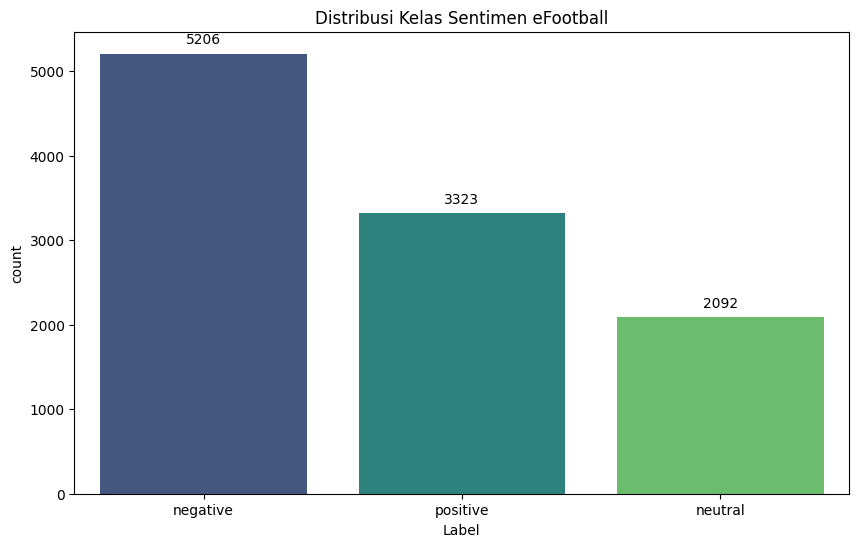

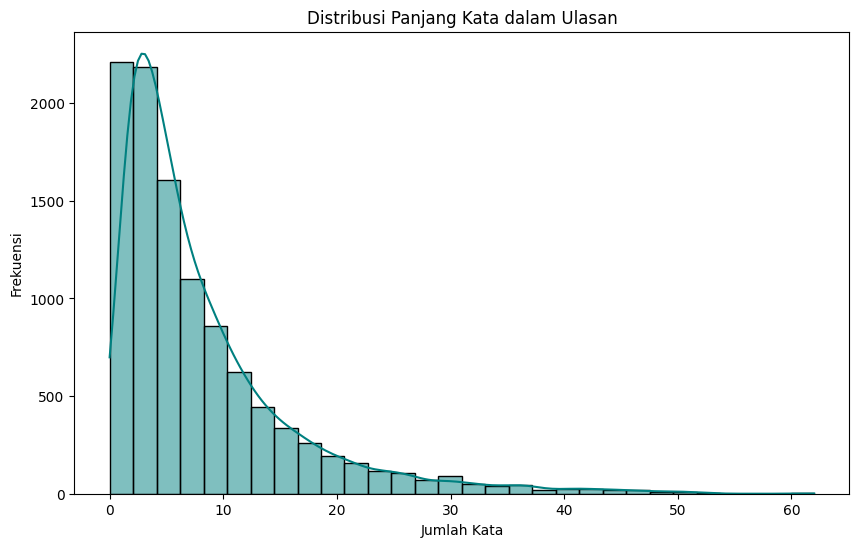

C:\Users\LOQ\AppData\Local\Temp\ipykernel_8076\3533122313.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bobot', y='kata', data=tfidf_df, palette='magma')


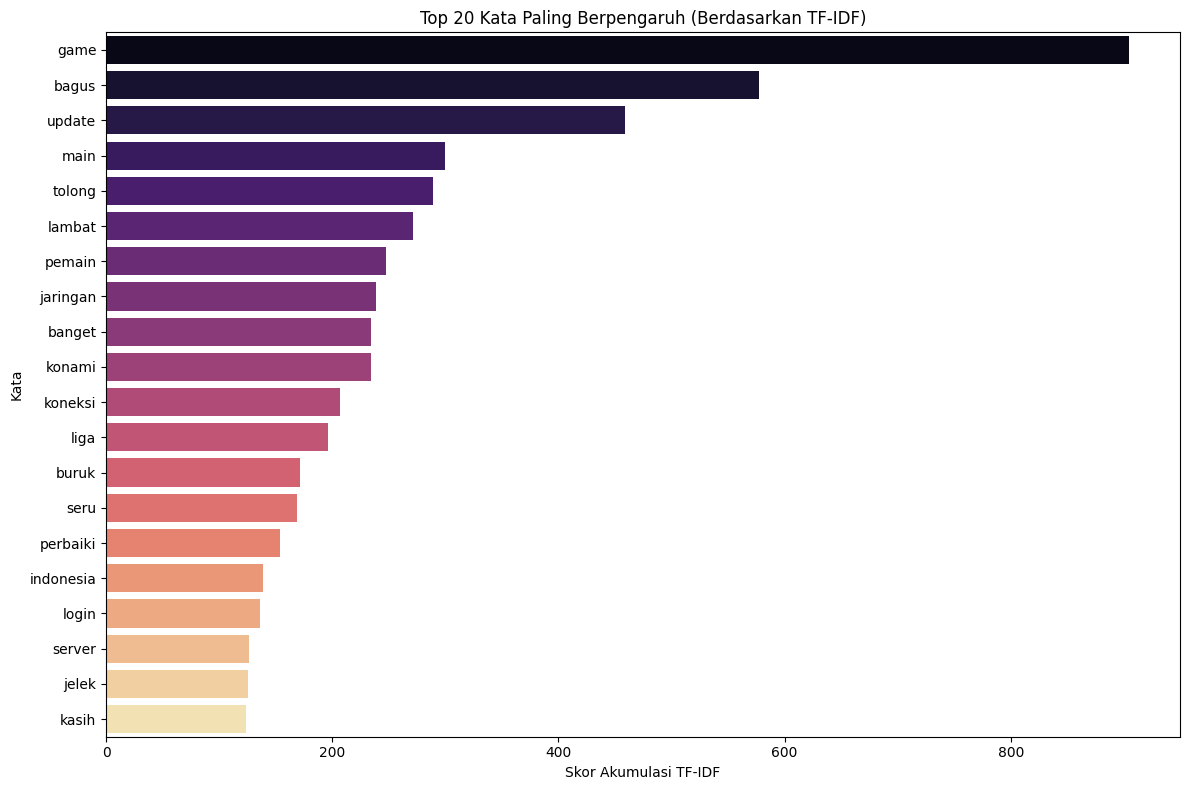

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# 1. Visualisasi Distribusi Kelas (Sentimen)
plt.figure(figsize=(10, 6))
# Kita pakai kolom 'Label' hasil proses sebelumnya
class_dist_plot = sns.countplot(x='Label', data=df, palette='viridis', order=['negative', 'positive', 'neutral'])
plt.title('Distribusi Kelas Sentimen eFootball')

# Menambahkan angka jumlah di atas bar
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')
plt.show()

# 2. Visualisasi Distribusi Panjang Teks (Jumlah Kata)
plt.figure(figsize=(10, 6))
# Menghitung jumlah kata di setiap ulasan
df['text_length'] = df['text_akhir'].apply(lambda x: len(str(x).split()))
sns.histplot(df['text_length'], bins=30, kde=True, color='teal')
plt.title('Distribusi Panjang Kata dalam Ulasan')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

# 3. Visualisasi Kata Paling Berpengaruh (Top 20 TF-IDF)
plt.figure(figsize=(12, 8))
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['text_akhir'].fillna(''))

# Menghitung bobot TF-IDF per kata
weights = np.asarray(X.sum(axis=0)).ravel()
tfidf_df = pd.DataFrame({'kata': vectorizer.get_feature_names_out(), 'bobot': weights})
tfidf_df = tfidf_df.sort_values('bobot', ascending=False).head(20)

sns.barplot(x='bobot', y='kata', data=tfidf_df, palette='magma')
plt.title('Top 20 Kata Paling Berpengaruh (Berdasarkan TF-IDF)')
plt.xlabel('Skor Akumulasi TF-IDF')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()

## Data Splitting 

In [13]:
df.head(2)

,Review,Rating,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,Label,text_length
0,boleh lah,5,boleh lah,boleh lah,boleh lah,"[boleh, lah]",[],,neutral,0
1,JARINGAN LU BENERIN NAPA KONAMEK,1,JARINGAN LU BENERIN NAPA KONAMEK,jaringan lu benerin napa konamek,jaringan kamu benerin kenapa konamek,"[jaringan, kamu, benerin, kenapa, konamek]","[jaringan, benerin, konamek]",jaringan benerin konamek,negative,3


In [14]:
# Pisahkan data menjadi fitur  dan label 
X = df['text_akhir']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Ekstraksi fitur menggunakan TF-IDF

In [15]:
tfidf = TfidfVectorizer(
    max_features=7000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1,2)  # optional tapi bagus
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

### Ekstraksi menggunakan Bag of Words (BOW)

In [16]:
# BOW (Bag of Words) dengan CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    max_features=3000,
    min_df=5,
    max_df=0.8
)
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

### Ekstraksi Binary Vectorization

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

cv_binary = CountVectorizer(
    max_features=5000,
    binary=True   
)

X_train_bin = cv_binary.fit_transform(X_train)
X_test_bin = cv_binary.transform(X_test)

### Kombinasi SVM dengan TF-IDF

In [18]:
from sklearn.svm import LinearSVC

model_svm_tfidf = LinearSVC(
    class_weight='balanced'
)

model_svm_tfidf.fit(X_train_tfidf, y_train)

# Prediksi
y_pred_train_svm = model_svm_tfidf.predict(X_train_tfidf)
y_pred_test_svm = model_svm_tfidf.predict(X_test_tfidf)

# Evaluasi
print("SVM Train:", accuracy_score(y_train, y_pred_train_svm))
print("SVM Test :", accuracy_score(y_test, y_pred_test_svm))

print(classification_report(y_test, y_pred_test_svm))

SVM Train: 0.9518596986817326
SVM Test : 0.8489411764705882
              precision    recall  f1-score   support

    negative       0.92      0.88      0.90      1042
     neutral       0.70      0.78      0.74       418
    positive       0.86      0.85      0.85       665

    accuracy                           0.85      2125
   macro avg       0.82      0.84      0.83      2125
weighted avg       0.85      0.85      0.85      2125



### Kombinasi SVM dengan BOW

In [19]:
from sklearn.svm import LinearSVC

model_svm_bow = LinearSVC(
    class_weight='balanced'
)

model_svm_bow.fit(X_train_cv, y_train)

# Prediksi
y_pred_train_svm = model_svm_bow.predict(X_train_cv)
y_pred_test_svm = model_svm_bow.predict(X_test_cv)

# Evaluasi
print("SVM Train:", accuracy_score(y_train, y_pred_train_svm))
print("SVM Test :", accuracy_score(y_test, y_pred_test_svm))

print(classification_report(y_test, y_pred_test_svm))

SVM Train: 0.9479755178907722
SVM Test : 0.8578823529411764
              precision    recall  f1-score   support

    negative       0.92      0.89      0.91      1042
     neutral       0.71      0.77      0.74       418
    positive       0.85      0.86      0.86       665

    accuracy                           0.86      2125
   macro avg       0.83      0.84      0.83      2125
weighted avg       0.86      0.86      0.86      2125



### Kombinasi Logistic Regression dengan BOW

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model_lr_bow = LogisticRegression(
    C=3,
    max_iter=3000,
    class_weight='balanced',
    n_jobs=-1
)

model_lr_bow.fit(X_train_cv, y_train)

# Prediksi
y_pred_train_lr = model_lr_bow.predict(X_train_cv)
y_pred_test_lr = model_lr_bow.predict(X_test_cv)

# Evaluasi
print("LogReg Train:", accuracy_score(y_train, y_pred_train_lr))
print("LogReg Test :", accuracy_score(y_test, y_pred_test_lr))

print(classification_report(y_test, y_pred_test_lr))

LogReg Train: 0.940560263653484
LogReg Test : 0.8395294117647059
              precision    recall  f1-score   support

    negative       0.93      0.85      0.89      1042
     neutral       0.66      0.82      0.73       418
    positive       0.85      0.84      0.85       665

    accuracy                           0.84      2125
   macro avg       0.81      0.84      0.82      2125
weighted avg       0.85      0.84      0.84      2125



### kombinasi SVM Binary Vectorization

In [21]:
model_svm_bin = LinearSVC(class_weight='balanced')
model_svm_bin.fit(X_train_bin, y_train)

# Evaluasi
from sklearn.metrics import accuracy_score, classification_report

y_pred_train = model_svm_bin.predict(X_train_bin)
y_pred_test = model_svm_bin.predict(X_test_bin)

print("SVM Binary Train:", accuracy_score(y_train, y_pred_train))
print("SVM Binary Test :", accuracy_score(y_test, y_pred_test))

print(classification_report(y_test, y_pred_test))

SVM Binary Train: 0.9777542372881356
SVM Binary Test : 0.8376470588235294
              precision    recall  f1-score   support

    negative       0.91      0.87      0.89      1042
     neutral       0.68      0.76      0.72       418
    positive       0.84      0.83      0.84       665

    accuracy                           0.84      2125
   macro avg       0.81      0.82      0.81      2125
weighted avg       0.84      0.84      0.84      2125



## kombinasi Logistic Regresion dengan Binary Vectorization

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model_lr_bin = LogisticRegression(
    C=3,
    max_iter=3000,
    class_weight='balanced',
    n_jobs=-1
)

model_lr_bin.fit(X_train_bin, y_train)

# Prediksi
y_pred_train_lr = model_lr_bin.predict(X_train_bin)
y_pred_test_lr = model_lr_bin.predict(X_test_bin)

# Evaluasi
print("LogReg Train:", accuracy_score(y_train, y_pred_train_lr))
print("LogReg Test :", accuracy_score(y_test, y_pred_test_lr))

print(classification_report(y_test, y_pred_test_lr))

LogReg Train: 0.9673964218455744
LogReg Test : 0.8367058823529412
              precision    recall  f1-score   support

    negative       0.93      0.84      0.88      1042
     neutral       0.66      0.81      0.72       418
    positive       0.85      0.85      0.85       665

    accuracy                           0.84      2125
   macro avg       0.81      0.83      0.82      2125
weighted avg       0.85      0.84      0.84      2125



# BUKTI INFERENCE

In [23]:
# Contoh teks baru
samples = [
    "game ini sangat seru dan menyenangkan",
    "biasa saja sih tidak terlalu menarik",
    "game ini jelek banget dan mengecewakan"
]

# Transform pakai TF-IDF yang SUDAH dilatih
samples_tfidf = tfidf.transform(samples)

# Prediksi menggunakan model SVM
predictions = model_svm_tfidf.predict(samples_tfidf)

# Tampilkan hasil
for text, pred in zip(samples, predictions):
    print(f"Teks: {text}")
    print(f"Prediksi: {pred}\n")

Teks: game ini sangat seru dan menyenangkan
Prediksi: positive

Teks: biasa saja sih tidak terlalu menarik
Prediksi: neutral

Teks: game ini jelek banget dan mengecewakan
Prediksi: negative



In [24]:
import pip


!pip freeze > requirements.txt